# Classification with Decision Trees and KNN

You will be using the loan dataset. Download the dataset and place the CSV file in your working directory.

### Import necessary libraries

In [1]:
# Data manipulation and analysis
import pandas as pd

# Machine learning models and evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
from sklearn import tree
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay

### Question 1: Decision Tree Classifiers

Step 1: Load the dataset

In [4]:
# add code here
df = pd.read_csv('Module3_Homework2_dataset.csv')
print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

   Age  Salary  Has_Loan
0   52   97750         1
1   30   58527         0
2   37   93150         0
3   58   76996         1
4   27   32124         0

Dataset shape: (100, 3)

Column names: ['Age', 'Salary', 'Has_Loan']


Step 2: Preprocess the dataset
- Using the *df.isnull().sum()* function, identify columns with missing values. In this dataset, the columns RankSeason, RankPlayoffs, OOBP, and OSLG have a majority of their values missing. For this exercise, drop these columns from the dataset to simplify the analysis.
- Encode categorical variables using label encoding.

{accuracy: 3}

In [6]:
# Handle missing values
df.isnull().sum()
# add code here
print("Missing values per column:")
print(df.isnull().sum())
# Scale features using StandardScaler()
scaler = StandardScaler()

Missing values per column:
Age         0
Salary      0
Has_Loan    0
dtype: int64


Step 3: Split the dataset into training and testing sets

{accuracy: 2}

In [11]:
# Define features and target
# add code here
X = df.drop('Has_Loan', axis=1)  
y = df['Has_Loan'] 

# Split the dataset using test_size = 0.2 and random_state = 42

# add code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (80, 2)
Testing set size: (20, 2)


Step 4: Train Decision Tree classifiers with different max_depth values

{accuracy: 4}

In [14]:
# Define max_depth values
max_depth_values = [3, 5, 7, 10]

# Train and evaluate Decision Tree classifiers
for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    # Fit the model using the training data

    # add code here
    model.fit(X_train_scaled, y_train)

    # Predict the labels for the training and the testing data

    # add code here
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calculate the error on the training and the testing data

    # add code here
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    # Print the results
    print(f"\nmax_depth = {max_depth}")
    print(f"Training Error: {train_error:.4f}")
    print(f"Testing Error: {test_error:.4f}")
    print(f"Training Accuracy: {(1 - train_error):.4f}")
    print(f"Testing Accuracy: {(1 - test_error):.4f}")


max_depth = 3
Training Error: 0.2750
Testing Error: 0.4000
Training Accuracy: 0.7250
Testing Accuracy: 0.6000

max_depth = 5
Training Error: 0.2000
Testing Error: 0.4000
Training Accuracy: 0.8000
Testing Accuracy: 0.6000

max_depth = 7
Training Error: 0.1500
Testing Error: 0.4000
Training Accuracy: 0.8500
Testing Accuracy: 0.6000

max_depth = 10
Training Error: 0.1250
Testing Error: 0.4000
Training Accuracy: 0.8750
Testing Accuracy: 0.6000


Step 5: Reduce dimensionality using PCA and visualize decision boundaries

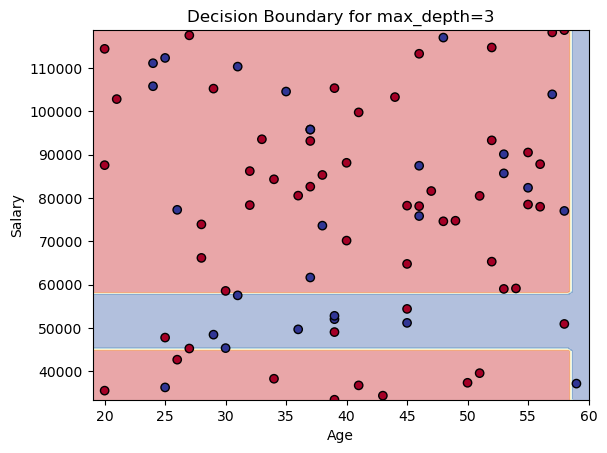

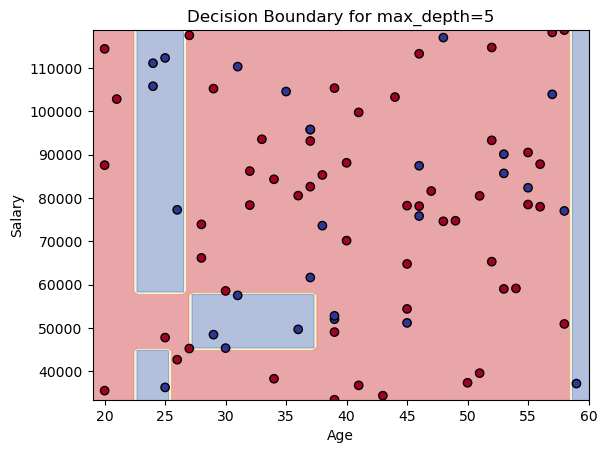

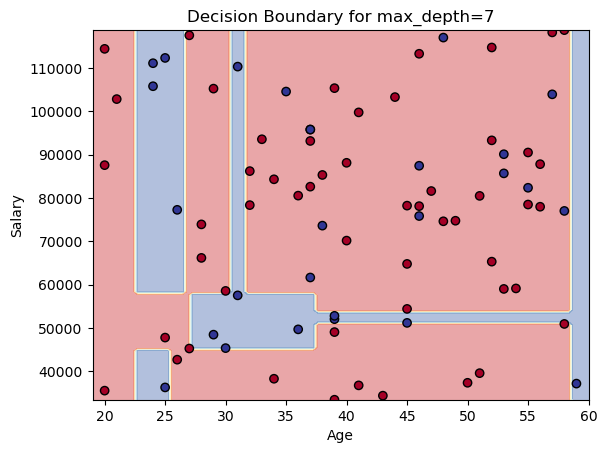

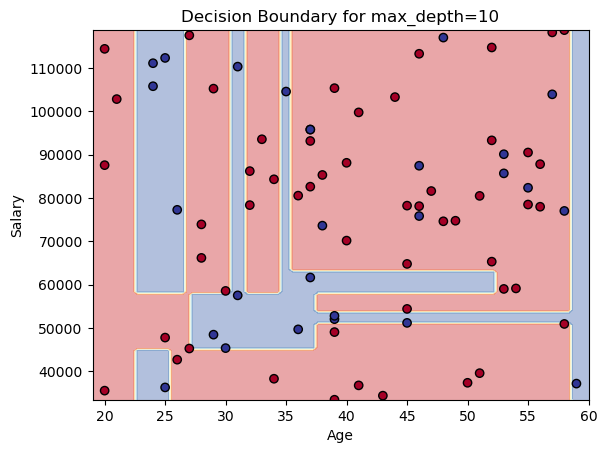

In [17]:
# Visualize Decision Tree classifiers with different max_depth values
for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Plot the decision boundary using DecisionBoundaryDisplay
    DecisionBoundaryDisplay.from_estimator(model, X_train, response_method="predict", cmap=plt.cm.RdYlBu, alpha=0.4)
    plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(f'Decision Boundary for max_depth={max_depth}')
    plt.show()

In [19]:
X_train.iloc[:,0]

55    55
88    37
26    39
42    37
69    46
      ..
60    55
71    57
14    51
92    20
51    29
Name: Age, Length: 80, dtype: int64

Step 6: Comment on the complexity of each model based on decision boundaries using a markdown cell

{reasoning: 2}

### Question 2: K-Nearest Neighbors (KNN) Classifiers

Step 1: Train KNN classifiers with different n_neighbors values

{accuracy: 3}

In [26]:
# Define n_neighbors values
n_neighbors_values = [3, 5, 7, 10]

# Train and evaluate KNN classifiers
for n_neighbors in n_neighbors_values:
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    # Fit the model using the training data
   
    # add code here
    model.fit(X_train_scaled, y_train)
    # Predict the labels for the training and the testing data

    # add code here
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate the error on the training and the testing data

    # add code here
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    # Print the results
    print(f"\nn_neighbors = {n_neighbors}")
    print(f"Training Error: {train_error:.4f}")
    print(f"Testing Error: {test_error:.4f}")
    print(f"Training Accuracy: {(1 - train_error):.4f}")
    print(f"Testing Accuracy: {(1 - test_error):.4f}")


n_neighbors = 3
Training Error: 0.2250
Testing Error: 0.4000
Training Accuracy: 0.7750
Testing Accuracy: 0.6000

n_neighbors = 5
Training Error: 0.3000
Testing Error: 0.4000
Training Accuracy: 0.7000
Testing Accuracy: 0.6000

n_neighbors = 7
Training Error: 0.2875
Testing Error: 0.5000
Training Accuracy: 0.7125
Testing Accuracy: 0.5000

n_neighbors = 10
Training Error: 0.3000
Testing Error: 0.4000
Training Accuracy: 0.7000
Testing Accuracy: 0.6000


Step 2: Visualize decision boundaries

{accuracy: 2}

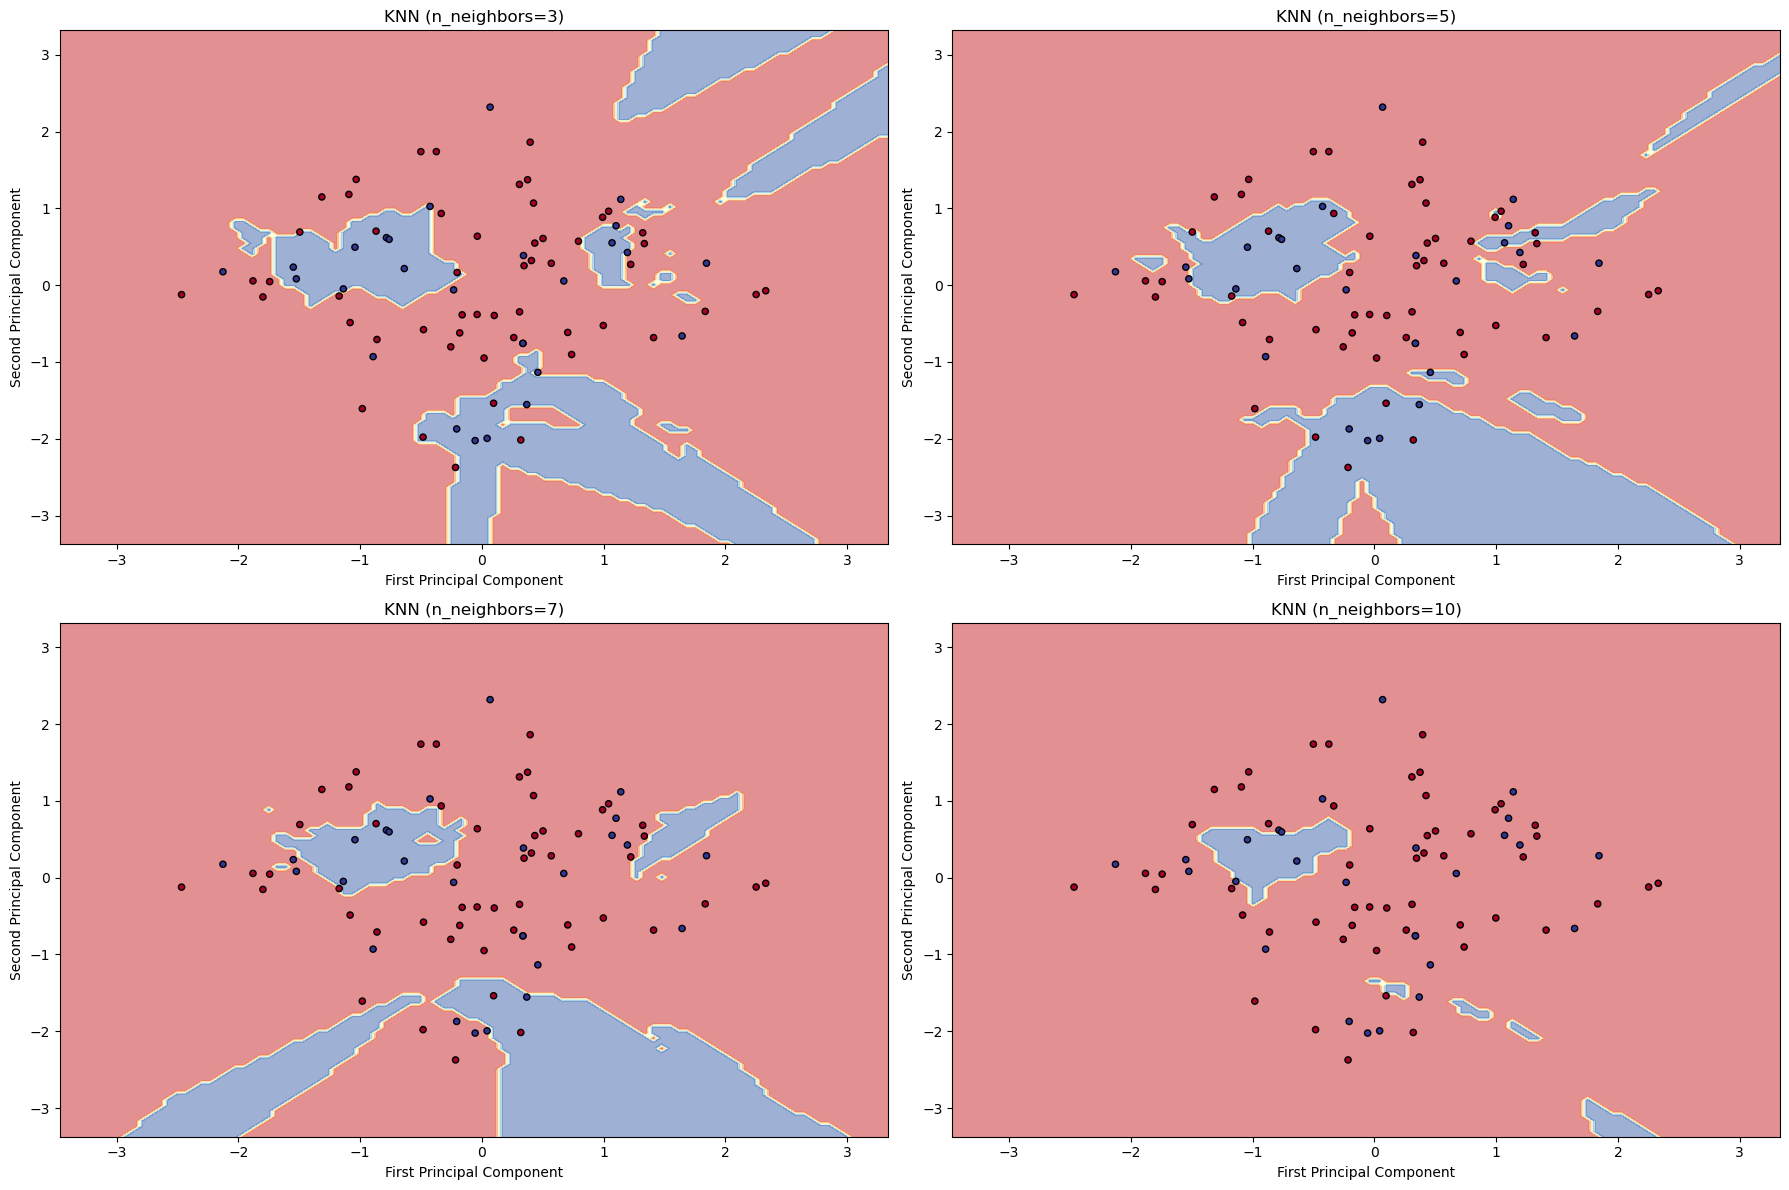

In [45]:
# Visualize KNN classifiers with different n_neighbors values usung the PCA reduced X train
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
# add code here
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for idx, n_neighbors in enumerate(n_neighbors_values):
    # Train model 
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train_pca, y_train)

# Plot the decision boundary using DecisionBoundaryDisplay

# add code here
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_pca,
        response_method='predict',
        cmap=plt.cm.RdYlBu,
        alpha=0.5,
        ax=axes[idx],
        xlabel='First Principal Component',
        ylabel='Second Principal Component'
    )

      #Scatter plot of training data
    axes[idx].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                     c=y_train, edgecolors='k', cmap=plt.cm.RdYlBu, s=20)

    axes[idx].set_title(f'KNN (n_neighbors={n_neighbors})', fontsize=12)

plt.tight_layout()
plt.show()

Step 3: Comment on the complexity of each model based on decision boundaries using a markdown cell

{reasoning: 2}

### Question 3: Decision Trees with Varying Depths

Step 1: Fit Decision Tree classifiers with max_depth values from 1 to 25

{accuracy: 2}

In [54]:
max_depth_range = range(1, 26)
train_errors = []
test_errors = []

# for max_depth in max_depth_range:
# add code here
for max_depth in max_depth_range:
    # Training Decision Tree model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Making predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculating errors
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)
    
    train_errors.append(train_error)
    test_errors.append(test_error)

print("Training and testing completed for depths 1 to 25")
print(f"Number of depth values tested: {len(train_errors)}")


Training and testing completed for depths 1 to 25
Number of depth values tested: 25


Step 2: Plot two curves for training and testing errors with max_depth on the x-axis and error on the y-axis.

{accuracy: 2}

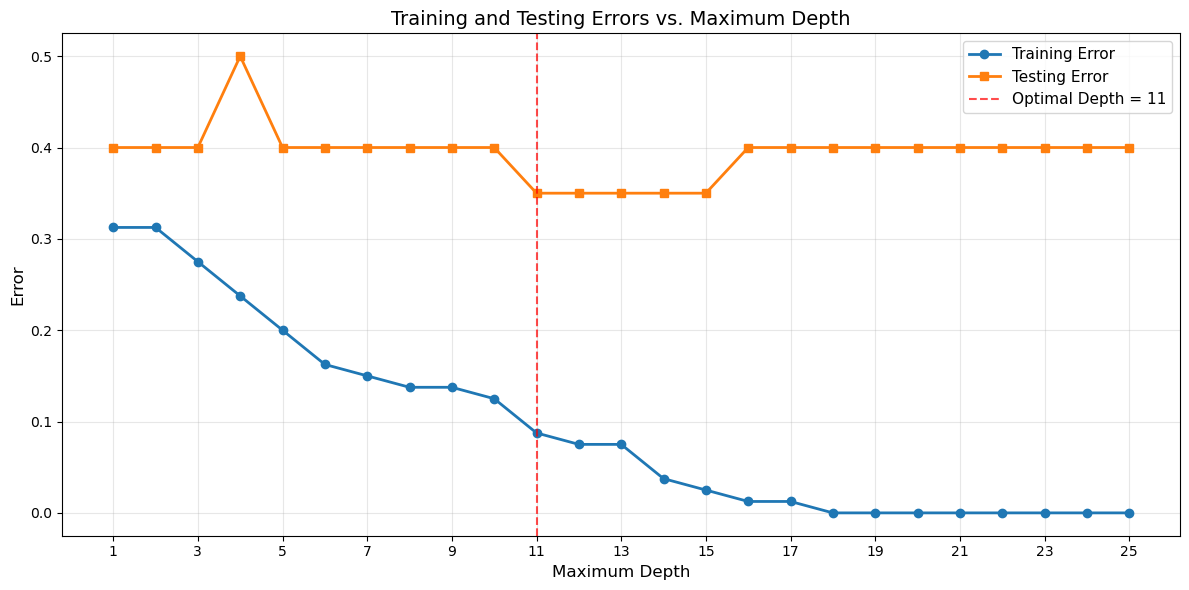

In [61]:
# add code here
plt.figure(figsize=(12, 6))
plt.plot(max_depth_range, train_errors, marker='o', label='Training Error', linewidth=2)
plt.plot(max_depth_range, test_errors, marker='s', label='Testing Error', linewidth=2)
plt.xlabel('Maximum Depth', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Training and Testing Errors vs. Maximum Depth', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 26, 2))

#Optimial depth 
optimal_depth = max_depth_range[np.argmin(test_errors)]
plt.axvline(x=optimal_depth, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal Depth = {optimal_depth}')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Step 3: Identify and explain the best depth using a markdown cell

{reasoning: 1}

### Question 4: Cross-Validation for Decision Trees

Use cross-validation to verify optimal depth and report the cross-validation scores and the mean score.

{accuracy: 2}

In [65]:
optimal_depth = max_depth_range[np.argmin(test_errors)]

# Evaluate with cross-validation and report the cross-validation scores and the mean score.
model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()
# add code here

# Print Results
print(f"Optimal Depth: {optimal_depth}")
print("\nCross-Validation Results (5-fold):")
print("=" * 50)
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold}: Accuracy = {score:.4f}")
print("=" * 50)
print(f"\nMean CV Accuracy: {mean_cv_score:.4f}")
print(f"Standard Deviation: {std_cv_score:.4f}")
print(f"95% Confidence Interval: [{mean_cv_score - 2*std_cv_score:.4f}, {mean_cv_score + 2*std_cv_score:.4f}]")
# add code here
final_model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
final_model.fit(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, final_model.predict(X_test_scaled))


Optimal Depth: 11

Cross-Validation Results (5-fold):
Fold 1: Accuracy = 0.5000
Fold 2: Accuracy = 0.5625
Fold 3: Accuracy = 0.4375
Fold 4: Accuracy = 0.6250
Fold 5: Accuracy = 0.6875

Mean CV Accuracy: 0.5625
Standard Deviation: 0.0884
95% Confidence Interval: [0.3857, 0.7393]
